# Modelos com validação temporal — LightGBM, Árvore de Decisão e Random Forest

Este notebook segue o mesmo protocolo de [`04_modelos_regressao_logistica.ipynb`](04_modelos_regressao_logistica.ipynb):

1. **Holdout por data** — treino até 09/03/2026, teste a partir de 10/03/2026
2. **Validação interna** com [`TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) (5 folds) apenas no conjunto de treino
3. **Avaliação final** no holdout futuro (dados nunca vistos na validação cruzada)

Objetivo: prever se o preço de um contrato Polymarket **sobe nos próximos 15 minutos** (`target = 1`).

In [1]:
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Carregamento dos dados

Preferência por `features/ml_features_v3.parquet` (com lags). Se não existir, construímos a partir de `ml_features_1m_v2.parquet`.

In [2]:
def build_v3_from_v2(raw: pl.DataFrame) -> pl.DataFrame:
    """Replica engenharia mínima do notebook 03_feature_engineering."""
    df = raw.sort(["market_id", "minute_bar"])
    df = df.with_columns(
        pl.when(pl.col("total_volume") > 0)
        .then((pl.col("buy_volume") - pl.col("sell_volume")) / pl.col("total_volume"))
        .otherwise(0.0)
        .alias("ofi_corrected")
    )
    lag_cols = [
        "close_mid",
        "depth_imbalance",
        "mean_spread",
        "close_spread",
        "bar_volatility",
        "ofi_corrected",
    ]
    return df.with_columns(
        [
            pl.col(col).shift(1).over("market_id").alias(f"{col}_lag1")
            for col in lag_cols
        ]
    )


def load_dataset() -> pl.DataFrame:
    candidates = [
        Path("features/ml_features_v3.parquet"),
        Path("features/ml_features_1m_v2.parquet"),
        Path("ml_features_1m_v2.parquet"),
    ]
    for path in candidates:
        if not path.exists():
            continue
        raw = pl.read_parquet(path)
        if "close_mid_lag1" in raw.columns:
            print(f"Carregado: {path} (já com lags)")
            return raw
        print(f"Carregado: {path} — gerando lags e ofi_corrected...")
        return build_v3_from_v2(raw)
    raise FileNotFoundError(
        "Nenhum parquet encontrado. Execute 03_feature_engineering.ipynb ou coloque "
        "features/ml_features_v3.parquet no projeto."
    )


df = load_dataset()
print(df.shape)
df.columns

Carregado: features\ml_features_1m_v2.parquet — gerando lags e ofi_corrected...
(5587547, 23)


['market_id',
 'minute_bar',
 'close_mid',
 'mean_spread',
 'close_spread',
 'bar_volatility',
 'total_volume',
 'buy_volume',
 'sell_volume',
 'trade_count',
 'order_flow_imbalance',
 'target',
 'return_1m',
 'bid_depth',
 'ask_depth',
 'depth_imbalance',
 'ofi_corrected',
 'close_mid_lag1',
 'depth_imbalance_lag1',
 'mean_spread_lag1',
 'close_spread_lag1',
 'bar_volatility_lag1',
 'ofi_corrected_lag1']

## Etapa 1 — Separação temporal (holdout)

- **Treino:** 06/03/2026 até 09/03/2026
- **Teste:** 10/03/2026 até 11/03/2026

Sem embaralhamento: o modelo só aprende com o passado e é avaliado no futuro.

In [3]:
CUTOFF = datetime(2026, 3, 10, tzinfo=timezone.utc)

train = df.filter(pl.col("minute_bar") < CUTOFF)
test = df.filter(pl.col("minute_bar") >= CUTOFF)

print("Treino:", train.shape)
print("Teste :", test.shape)

print(train.select(pl.min("minute_bar").alias("início"), pl.max("minute_bar").alias("fim")))
print(test.select(pl.min("minute_bar").alias("início"), pl.max("minute_bar").alias("fim")))

Treino: (4948403, 23)
Teste : (639144, 23)
shape: (1, 2)
┌─────────────────────────┬─────────────────────────┐
│ início                  ┆ fim                     │
│ ---                     ┆ ---                     │
│ datetime[μs, UTC]       ┆ datetime[μs, UTC]       │
╞═════════════════════════╪═════════════════════════╡
│ 2026-03-06 00:00:00 UTC ┆ 2026-03-09 23:59:00 UTC │
└─────────────────────────┴─────────────────────────┘
shape: (1, 2)
┌─────────────────────────┬─────────────────────────┐
│ início                  ┆ fim                     │
│ ---                     ┆ ---                     │
│ datetime[μs, UTC]       ┆ datetime[μs, UTC]       │
╞═════════════════════════╪═════════════════════════╡
│ 2026-03-10 00:00:00 UTC ┆ 2026-03-11 23:59:00 UTC │
└─────────────────────────┴─────────────────────────┘


### Mercados em comum entre treino e teste

In [4]:
train_markets = set(train["market_id"].unique().to_list())
test_markets = set(test["market_id"].unique().to_list())
common = train_markets & test_markets

print(f"Mercados no treino: {len(train_markets)}")
print(f"Mercados no teste : {len(test_markets)}")
print(f"Mercados em comum : {len(common)}")
print(f"Percentual em comum: {100 * len(common) / len(test_markets):.2f}%")
print(f"Apenas no teste   : {len(test_markets - train_markets)}")

Mercados no treino: 4070
Mercados no teste : 1502
Mercados em comum : 862
Percentual em comum: 57.39%
Apenas no teste   : 640


### Distribuição do target

In [5]:
print("Treino:")
display(
    train.group_by("target").len().with_columns(
        (pl.col("len") / train.height * 100).alias("percentual")
    )
)
print("Teste:")
display(
    test.group_by("target").len().with_columns(
        (pl.col("len") / test.height * 100).alias("percentual")
    )
)

Treino:


target,len,percentual
i8,u32,f64
0,3630505,73.367206
1,1317898,26.632794


Teste:


target,len,percentual
i8,u32,f64
0,467953,73.215582
1,171191,26.784418


### Nulls nas variáveis de lag (antes de remover)

Como eles existem apenas nas variáveis de lag, removemos somente as linhas com null nessas colunas.

In [6]:
lag_cols = [
    "close_mid_lag1",
    "depth_imbalance_lag1",
    "mean_spread_lag1",
    "close_spread_lag1",
    "bar_volatility_lag1",
    "ofi_corrected_lag1",
]

print("Nulls no treino:", train.select([pl.col(c).is_null().sum().alias(c) for c in lag_cols]))
print("Nulls no teste :", test.select([pl.col(c).is_null().sum().alias(c) for c in lag_cols]))

Nulls no treino: shape: (1, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ close_mid_lag1 ┆ depth_imbalanc ┆ mean_spread_la ┆ close_spread_ ┆ bar_volatilit ┆ ofi_corrected │
│ ---            ┆ e_lag1         ┆ g1             ┆ lag1          ┆ y_lag1        ┆ _lag1         │
│ u32            ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           │
│                ┆ u32            ┆ u32            ┆ u32           ┆ u32           ┆ u32           │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 4070           ┆ 4070           ┆ 4070           ┆ 4070          ┆ 4070          ┆ 4070          │
└────────────────┴────────────────┴────────────────┴───────────────┴───────────────┴───────────────┘
Nulls no teste : shape: (1, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ close_mid_lag1 ┆ depth_imba

In [7]:
train = train.drop_nulls(lag_cols)
test = test.drop_nulls(lag_cols)

print("Após remover nulls de lag — Treino:", train.shape, "| Teste:", test.shape)

Após remover nulls de lag — Treino: (4944333, 23) | Teste: (638504, 23)


In [8]:
features = [
    "close_mid",
    "depth_imbalance",
    "mean_spread",
    "close_spread",
    "bar_volatility",
    "ofi_corrected",
    "close_mid_lag1",
    "depth_imbalance_lag1",
    "mean_spread_lag1",
    "close_spread_lag1",
    "bar_volatility_lag1",
    "ofi_corrected_lag1",
]

X_train = train.select(features).to_pandas()
y_train = train["target"].to_numpy().ravel()
X_test = test.select(features).to_pandas()
y_test = test["target"].to_numpy().ravel()

baseline_acc = float((y_test == 0).mean())
print(f"Baseline (sempre classe 0): {baseline_acc:.4f}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Baseline (sempre classe 0): 0.7322
X_train: (4944333, 12) | X_test: (638504, 12)


## Etapa 2 — Validação com TimeSeriesSplit

O [`TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) expande a janela de treino a cada fold e valida sempre em um bloco **futuro** dentro do conjunto de treino:

| Fold | Treino | Validação |
|------|--------|-----------|
| 1 | início | próximo bloco |
| 2 | início + fold 1 | bloco seguinte |
| ... | histórico acumulado | sempre à frente no tempo |

Modelos de árvore **não** precisam de `StandardScaler`.

In [10]:
def make_model(name: str):
    if name == "LightGBM":
        return lgb.LGBMClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=5,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
            verbose=-1,
        )
    if name == "Decision Tree":
        return DecisionTreeClassifier(
            max_depth=10,
            random_state=42,
            class_weight="balanced",
        )
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
        )
    raise ValueError(name)


MODEL_NAMES = ["LightGBM", "Decision Tree", "Random Forest"]

In [11]:
def timeseries_cv(model_name: str, n_splits: int = 5) -> dict:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    metrics = {"auc": [], "f1": [], "precision": [], "recall": [], "accuracy": []}

    print(f"\n{'=' * 50}")
    print(f"TimeSeriesSplit — {model_name}")
    print(f"{'=' * 50}")

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]

        model = make_model(model_name)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        fold_metrics = {
            "auc": roc_auc_score(y_val, y_proba),
            "f1": f1_score(y_val, y_pred, zero_division=0),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "recall": recall_score(y_val, y_pred, zero_division=0),
            "accuracy": accuracy_score(y_val, y_pred),
        }
        for k, v in fold_metrics.items():
            metrics[k].append(v)

        print(
            f"Fold {fold} — AUC: {fold_metrics['auc']:.4f} | "
            f"F1: {fold_metrics['f1']:.4f} | "
            f"Prec: {fold_metrics['precision']:.4f} | "
            f"Recall: {fold_metrics['recall']:.4f}"
        )

    summary = {k: (float(np.mean(v)), float(np.std(v))) for k, v in metrics.items()}
    print(
        f"\nMédias — AUC: {summary['auc'][0]:.4f} ± {summary['auc'][1]:.4f} | "
        f"F1: {summary['f1'][0]:.4f} ± {summary['f1'][1]:.4f}"
    )
    return summary


cv_results = {name: timeseries_cv(name) for name in MODEL_NAMES}


TimeSeriesSplit — LightGBM
Fold 1 — AUC: 0.8878 | F1: 0.6362 | Prec: 0.5279 | Recall: 0.8005
Fold 2 — AUC: 0.8815 | F1: 0.6496 | Prec: 0.5365 | Recall: 0.8232
Fold 3 — AUC: 0.8980 | F1: 0.6883 | Prec: 0.5660 | Recall: 0.8782
Fold 4 — AUC: 0.8971 | F1: 0.6550 | Prec: 0.5395 | Recall: 0.8335
Fold 5 — AUC: 0.8938 | F1: 0.7089 | Prec: 0.6080 | Recall: 0.8501

Médias — AUC: 0.8917 ± 0.0062 | F1: 0.6676 ± 0.0269

TimeSeriesSplit — Decision Tree
Fold 1 — AUC: 0.8628 | F1: 0.6422 | Prec: 0.5690 | Recall: 0.7371
Fold 2 — AUC: 0.8615 | F1: 0.6473 | Prec: 0.5616 | Recall: 0.7638
Fold 3 — AUC: 0.8801 | F1: 0.6628 | Prec: 0.5524 | Recall: 0.8284
Fold 4 — AUC: 0.8875 | F1: 0.6348 | Prec: 0.5328 | Recall: 0.7850
Fold 5 — AUC: 0.8831 | F1: 0.7009 | Prec: 0.6064 | Recall: 0.8303

Médias — AUC: 0.8750 ± 0.0108 | F1: 0.6576 ± 0.0235

TimeSeriesSplit — Random Forest
Fold 1 — AUC: 0.8878 | F1: 0.6487 | Prec: 0.5477 | Recall: 0.7953
Fold 2 — AUC: 0.8810 | F1: 0.6435 | Prec: 0.5408 | Recall: 0.7943
Fold 3 —

In [12]:
cv_rows = []
for name in MODEL_NAMES:
    s = cv_results[name]
    cv_rows.append({
        "Modelo": name,
        "ROC-AUC (média)": s["auc"][0],
        "ROC-AUC (std)": s["auc"][1],
        "F1 (média)": s["f1"][0],
        "F1 (std)": s["f1"][1],
        "Precision (média)": s["precision"][0],
        "Recall (média)": s["recall"][0],
    })

pd.DataFrame(cv_rows).sort_values("ROC-AUC (média)", ascending=False)

,Modelo,ROC-AUC (média),ROC-AUC (std),F1 (média),F1 (std),Precision (média),Recall (média)
0,LightGBM,0.891658,0.006188,0.667628,0.026852,0.555566,0.837105
2,Random Forest,0.890197,0.005425,0.669418,0.026698,0.563754,0.824301
1,Decision Tree,0.875023,0.010765,0.657601,0.023511,0.564436,0.788931


## Etapa 3 — Treino final e holdout

Cada modelo é treinado no **treino completo** (até 09/03) e avaliado no holdout (10–11/03), simulando previsão em dados futuros reais.

In [13]:
final_models = {}
holdout_results = []

for name in MODEL_NAMES:
    model = make_model(name)
    model.fit(X_train, y_train)
    final_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    holdout_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

    print(f"\n===== HOLDOUT — {name} =====")
    for k, v in holdout_results[-1].items():
        if k != "Modelo":
            print(f"{k}: {v:.4f}")

holdout_df = pd.DataFrame(holdout_results).sort_values("ROC-AUC", ascending=False)
holdout_df


===== HOLDOUT — LightGBM =====
Accuracy: 0.7537
Precision: 0.5226
Recall: 0.9264
F1-Score: 0.6682
ROC-AUC: 0.9057

===== HOLDOUT — Decision Tree =====
Accuracy: 0.7598
Precision: 0.5295
Recall: 0.9218
F1-Score: 0.6727
ROC-AUC: 0.9025

===== HOLDOUT — Random Forest =====
Accuracy: 0.7536
Precision: 0.5224
Recall: 0.9283
F1-Score: 0.6686
ROC-AUC: 0.9112


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.753590,0.522428,0.928276,0.668582,0.911201
0,LightGBM,0.753698,0.522596,0.926351,0.668219,0.905675
1,Decision Tree,0.759774,0.529527,0.921806,0.672652,0.902453


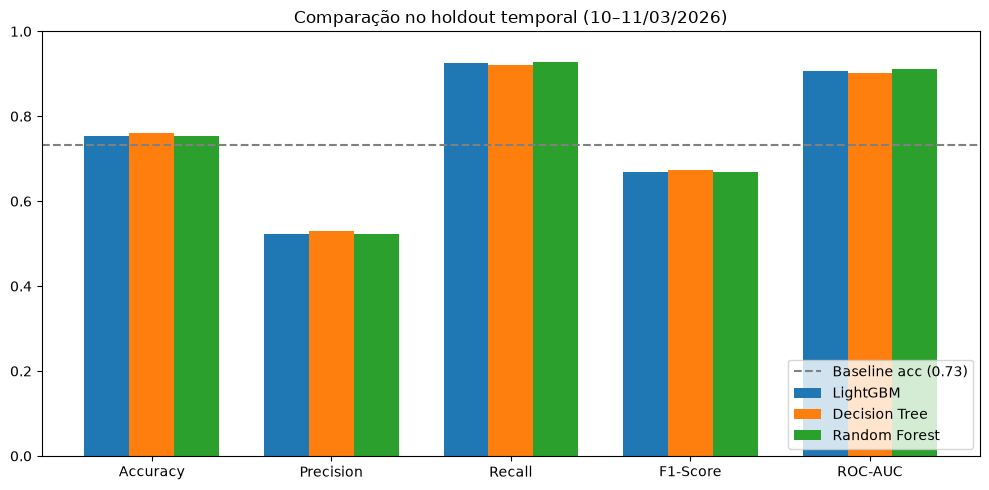

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metrics_plot))
width = 0.25

for i, name in enumerate(MODEL_NAMES):
    row = holdout_df[holdout_df["Modelo"] == name].iloc[0]
    values = [row[m] for m in metrics_plot]
    ax.bar(x + i * width, values, width, label=name)

ax.axhline(baseline_acc, color="gray", linestyle="--", label=f"Baseline acc ({baseline_acc:.2f})")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot)
ax.set_ylim(0, 1)
ax.set_title("Comparação no holdout temporal (10–11/03/2026)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

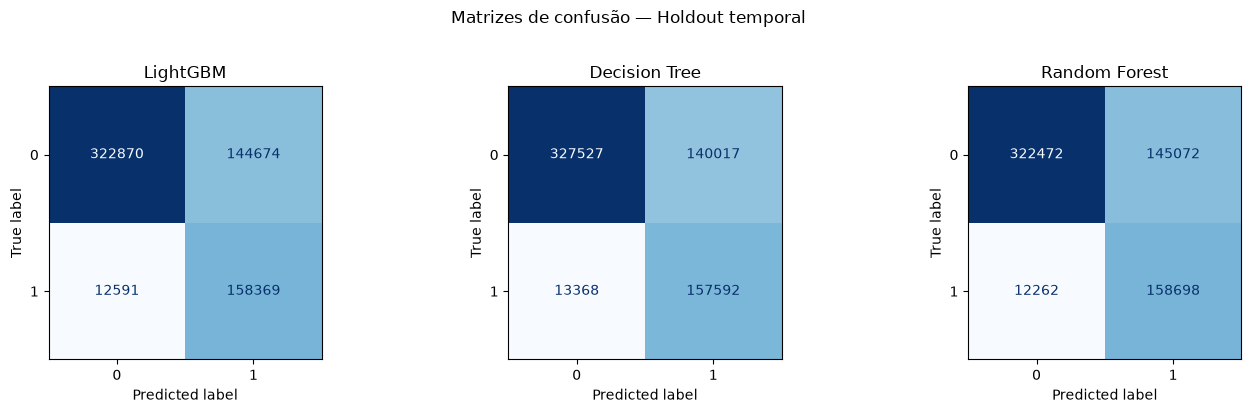

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, MODEL_NAMES):
    model = final_models[name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.suptitle("Matrizes de confusão — Holdout temporal", y=1.02)
plt.tight_layout()
plt.show()

## Importância das features (LightGBM e Random Forest)

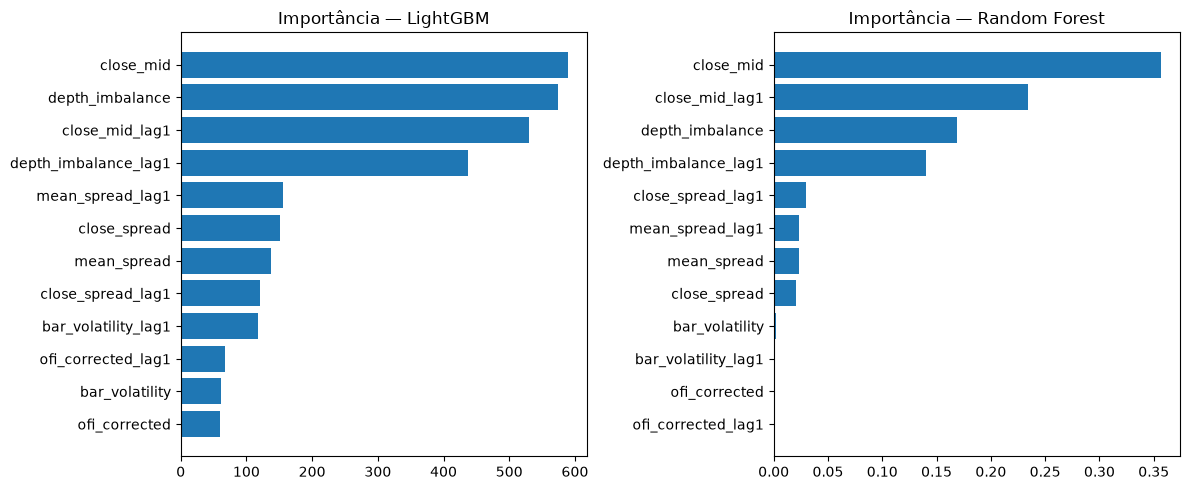

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, ["LightGBM", "Random Forest"]):
    model = final_models[name]
    importances = model.feature_importances_
    order = np.argsort(importances)
    ax.barh(np.array(features)[order], importances[order])
    ax.set_title(f"Importância — {name}")

plt.tight_layout()
plt.show()

## Síntese

- A validação com **TimeSeriesSplit** estima desempenho em cenários walk-forward sem usar dados futuros no treino de cada fold.
- O **holdout por data** é a avaliação definitiva: período 10–11/03 nunca entrou na validação cruzada.
- Compare ROC-AUC e F1 entre modelos; lembre que ~73% dos exemplos são classe 0 — acurácia isolada pode ser enganosa.
- Para referência, a Regressão Logística com o mesmo protocolo está em `04_modelos_regressao_logistica.ipynb`.